# 🏥 ICD-Insight — Notebook A: QLoRA Training
### BioClinical ModernBERT + QLoRA Fine-tuning on Public Hugging Face Dataset

> **M.Tech Final Year Project** | ICD-10 Multi-Label Classification  
> Run on **Google Colab Free Tier (T4 GPU)**

---

**What this notebook does:**
1. Installs all dependencies
2. Mounts Google Drive for checkpoint saving
3. Downloads and preprocesses `birgermoell/icd10-clinical-notes` (100% public, no DUA needed)
4. Fine-tunes BioClinical ModernBERT with **QLoRA** (4-bit quantized base + LoRA adapters)
5. Evaluates on held-out test set
6. Saves LoRA adapter weights (~20–50 MB) to Drive for GitHub upload

**Prerequisites:**
- ✅ Clone this repo to colab so `src/preprocess.py` is available
- ✅ Runtime set to **GPU → T4** (Runtime → Change runtime type → T4 GPU)

## A.0 — Hardware Check

In [1]:
import subprocess, torch

print("=" * 60)
print("GPU INFO")
print("=" * 60)
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"  GPU Name  : {gpu.name}")
    print(f"  VRAM      : {gpu.total_memory / 1e9:.1f} GB")
    print(f"  CUDA ver  : {torch.version.cuda}")
else:
    print("  ⚠ No GPU detected! Go to Runtime → Change runtime type → T4 GPU")

result = subprocess.run(["df", "-h", "/"], capture_output=True, text=True)
print("\nDISK SPACE")
print(result.stdout)

import psutil
ram = psutil.virtual_memory()
print(f"RAM       : {ram.total / 1e9:.1f} GB total, {ram.available / 1e9:.1f} GB available")

GPU INFO
  GPU Name  : Tesla T4
  VRAM      : 15.6 GB
  CUDA ver  : 12.8

DISK SPACE
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /

RAM       : 13.6 GB total, 11.5 GB available


## A.1 — Install Dependencies

> ⏱ Takes ~3–5 minutes on first run. Restart runtime if prompted.

In [4]:
# NOTE: ModernBERT requires transformers>=4.48. The previous pin (4.41.0) cannot
# load `model_type: modernbert`. Versions below are a known-compatible QLoRA set.
!pip install -U \
  transformers==4.49.0 \
  peft==0.14.0 \
  accelerate==1.2.1 \
  datasets==3.2.0 \
  evaluate==0.4.2 \
  bitsandbytes==0.46.1 \
  scikit-learn==1.6.1

print("Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 106.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.45.0
    Uninstalling bitsandbytes-0.45.0:
      Successfully uninstalled bitsandbytes-0.45.0


Dependencies installed


In [1]:
import torch
import transformers
import peft
import bitsandbytes as bnb

print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"peft         : {peft.__version__}")
print(f"bitsandbytes : {bnb.__version__}")
print(f"CUDA avail   : {torch.cuda.is_available()}")

torch        : 2.11.0+cu128
transformers : 4.49.0
peft         : 0.14.0
bitsandbytes : 0.46.1
CUDA avail   : True


## A.2 — Mount Google Drive

Checkpoints are saved here mid-training so they survive session timeouts.

In [2]:
# Drive mount is optional. For an unattended "Run all", we skip the interactive
# OAuth popup and back up checkpoints to a local directory instead. If you WANT
# Drive persistence, set USE_DRIVE = True and authorize when prompted.
import os
USE_DRIVE = False

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/icd-insight/checkpoints"
else:
    DRIVE_CHECKPOINT_DIR = "/content/checkpoints_backup"

os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
print(f"✅ Checkpoint backup dir: {DRIVE_CHECKPOINT_DIR} (USE_DRIVE={USE_DRIVE})")

✅ Checkpoint backup dir: /content/checkpoints_backup (USE_DRIVE=False)


## A.3 — Dataset Download & Preprocessing

We will use the public `birgermoell/icd10-clinical-notes` dataset from Hugging Face.  
To run the preprocessing script, we first need to clone our GitHub repo.

In [3]:
# ─── CONFIGURATION — Edit these values ───────────────────────────────────────

# NOTE: `NLP4Science/BioClinical-ModernBERT-base` is not publicly accessible (HTTP 401).
# Using the canonical public BioClinical ModernBERT (MIT license, same 150M model).
BASE_MODEL_ID  = "thomas-sounack/BioClinical-ModernBERT-base"
TOP_K_CODES    = 50          # number of most-frequent ICD-10 codes to target
MAX_NOTES      = 60000       # cap on notes (dataset is ~1.8k, so all are used)
MAX_LENGTH     = 2048        # token length — safe for T4 16 GB with QLoRA
BATCH_SIZE     = 4
GRAD_ACCUM     = 8           # effective batch = 4 × 8 = 32
LEARNING_RATE  = 2e-4
NUM_EPOCHS     = 5
LORA_R         = 16
LORA_ALPHA     = 32
THRESHOLD      = 0.5         # sigmoid threshold for positive label
SEED           = 42

LOCAL_DATA_DIR = "/content/data/processed"
LOCAL_CKPT_DIR = "/content/checkpoints"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

print("Configuration:")
print(f"  Base model  : {BASE_MODEL_ID}")
print(f"  Max length  : {MAX_LENGTH} tokens")
print(f"  Batch size  : {BATCH_SIZE} (× {GRAD_ACCUM} grad accum = {BATCH_SIZE*GRAD_ACCUM} effective)")
print(f"  LoRA rank   : r={LORA_R}, alpha={LORA_ALPHA}")
print(f"  Epochs      : {NUM_EPOCHS}")

Configuration:
  Base model  : thomas-sounack/BioClinical-ModernBERT-base
  Max length  : 2048 tokens
  Batch size  : 4 (× 8 grad accum = 32 effective)
  LoRA rank   : r=16, alpha=32
  Epochs      : 5


In [4]:
# Clone the repo to get src/preprocess.py (branch with the src/ package)
import os, subprocess
REPO_DIR = "/content/icd-insight"
GITHUB_REPO = "https://github.com/Narsapuram-Mamatha/icd-insight.git"
REPO_BRANCH = "feature/training-pipeline-execution"

if not os.path.exists(REPO_DIR):
    print(f"▶ Cloning {GITHUB_REPO} (branch {REPO_BRANCH}) …")
    subprocess.run(
        ["git", "clone", "--branch", REPO_BRANCH, "--single-branch", GITHUB_REPO, REPO_DIR],
        check=True,
    )
else:
    print("▶ Repo already cloned.")

print("\n▶ Running preprocessing pipeline …")
!python {REPO_DIR}/src/preprocess.py \
    --output_dir {LOCAL_DATA_DIR} \
    --top_k_codes {TOP_K_CODES} \
    --max_notes {MAX_NOTES}


▶ Cloning https://github.com/Narsapuram-Mamatha/icd-insight.git (branch feature/training-pipeline-execution) …

▶ Running preprocessing pipeline …
▶ Loading dataset from Hugging Face: birgermoell/icd10-clinical-notes …
README.md: 4.86kB [00:00, 15.8MB/s]
train.jsonl: 317kB [00:00, 48.3MB/s]
test.jsonl: 79.6kB [00:00, 40.7MB/s]
Generating train split: 100% 1441/1441 [00:00<00:00, 101559.22 examples/s]
Generating test split: 100% 361/361 [00:00<00:00, 126865.84 examples/s]
  Total records downloaded: 1,441
▶ Filtering and cleaning …
  Keeping all languages: 1,441 records
  Notes after filtering empty text: 1,441
  Top-50 codes cover 50 unique codes
  Records with at least 1 top-50 code: 1,375
  Train: 1,145 | Val: 115 | Test: 115
  Saved /content/data/processed/train.jsonl
  Saved /content/data/processed/val.jsonl
  Saved /content/data/processed/test.jsonl
  Saved /content/data/processed/label_binarizer.pkl
  Saved descriptions to /content/data/processed/icd10_descriptions.tsv
✅ Preproce

## A.4 — Tokenization & Dataset Class

In [5]:
import torch
import json
import pickle
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

class ICD10Dataset(Dataset):
    def __init__(self, jsonl_path, tokenizer, mlb, max_length=2048):
        self.tokenizer = tokenizer
        self.mlb = mlb
        self.max_length = max_length
        self.records = []
        with open(jsonl_path) as f:
            for line in f:
                self.records.append(json.loads(line))

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        enc = self.tokenizer(
            rec["text"], max_length=self.max_length,
            truncation=True, padding="max_length", return_tensors="pt"
        )
        label_vec = self.mlb.transform([rec["labels"]])[0]
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(label_vec, dtype=torch.float),
        }

print("▶ Loading tokenizer …")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
print(f"  Vocab size : {tokenizer.vocab_size:,}")
print(f"  Max length : {MAX_LENGTH}")

# Load MultiLabelBinarizer
MLB_PATH = f"{LOCAL_DATA_DIR}/label_binarizer.pkl"
with open(MLB_PATH, "rb") as f:
    MLB = pickle.load(f)

train_ds = ICD10Dataset(f"{LOCAL_DATA_DIR}/train.jsonl", tokenizer, MLB, MAX_LENGTH)
val_ds   = ICD10Dataset(f"{LOCAL_DATA_DIR}/val.jsonl",   tokenizer, MLB, MAX_LENGTH)
test_ds  = ICD10Dataset(f"{LOCAL_DATA_DIR}/test.jsonl",  tokenizer, MLB, MAX_LENGTH)

print(f"  Train examples : {len(train_ds):,}")
print(f"  Val examples   : {len(val_ds):,}")
print(f"  Test examples  : {len(test_ds):,}")

# Quick check
sample = train_ds[0]
print(f"  Sample input_ids shape : {sample['input_ids'].shape}")
print(f"  Sample labels shape    : {sample['labels'].shape}")

▶ Loading tokenizer …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

  Vocab size : 50,280
  Max length : 2048
  Train examples : 1,145
  Val examples   : 115
  Test examples  : 115
  Sample input_ids shape : torch.Size([2048])
  Sample labels shape    : torch.Size([50])


## A.5 — Load Model in 4-bit (QLoRA)

Base model loaded in NF4 quantization (~2 GB VRAM).  
LoRA adapters attached (~4–8 M trainable parameters out of 150 M total).

In [6]:
from transformers import AutoModelForSequenceClassification, BitsAndBytesConfig
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

NUM_LABELS = len(MLB.classes_)
print(f"▶ Loading {BASE_MODEL_ID} in 4-bit NF4 ({NUM_LABELS} labels) …")

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load base model.
# T4 (Turing) does not support FlashAttention-2, so use eager attention and
# disable ModernBERT's torch.compile path for stable QLoRA training.
base_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL_ID,
    num_labels=NUM_LABELS,
    quantization_config=bnb_config,
    device_map="auto",
    problem_type="multi_label_classification",
    attn_implementation="eager",
    reference_compile=False,
)

# Prepare for k-bit training
base_model = prepare_model_for_kbit_training(base_model)

# LoRA configuration — ModernBERT attention/MLP linears are named Wqkv / Wo / Wi.
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["Wqkv", "Wo"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved() / 1e9
    print(f"\n  VRAM allocated : {allocated:.2f} GB")
    print(f"  VRAM reserved  : {reserved:.2f} GB")

▶ Loading thomas-sounack/BioClinical-ModernBERT-base in 4-bit NF4 (50 labels) …


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at thomas-sounack/BioClinical-ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 2,336,306 || all params: 151,979,620 || trainable%: 1.5372

  VRAM allocated : 0.22 GB
  VRAM reserved  : 0.30 GB


## A.6 — Training Configuration

In [7]:
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        prob = torch.sigmoid(logits)
        p_t  = prob * targets + (1 - prob) * (1 - targets)
        return ((1 - p_t) ** self.gamma * bce).mean()

focal_loss_fn = FocalLoss(gamma=2.0)
print("✅ Focal loss ready (gamma=2.0)")

✅ Focal loss ready (gamma=2.0)


In [8]:
from transformers import TrainingArguments, Trainer
import evaluate, numpy as np
from sklearn.metrics import f1_score, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs >= THRESHOLD).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)

    try:
        auc = roc_auc_score(labels, probs, average="micro")
    except Exception:
        auc = 0.0

    return {"micro_f1": micro_f1, "macro_f1": macro_f1, "auc_roc": auc}


class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss    = focal_loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir=LOCAL_CKPT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.10,
    lr_scheduler_type="cosine",
    fp16=True,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("✅ Trainer configured")
steps_per_epoch = len(train_ds) // (BATCH_SIZE * GRAD_ACCUM)
print(f"   Effective steps/epoch : {steps_per_epoch:,}")
print(f"   Total training steps  : {steps_per_epoch * NUM_EPOCHS:,}")

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


✅ Trainer configured
   Effective steps/epoch : 35
   Total training steps  : 175


## A.7 — Training

> ⏱ Expected time: ~1.5–2 hours on T4.  
> Checkpoints are saved every epoch to Google Drive automatically.

In [9]:
print("🚀 Starting training …")
print(f"   Model : {BASE_MODEL_ID}")
print(f"   LoRA  : r={LORA_R}, alpha={LORA_ALPHA}")
print(f"   Batch : {BATCH_SIZE} × {GRAD_ACCUM} grad accum = {BATCH_SIZE*GRAD_ACCUM} effective")
print(f"   LR    : {LEARNING_RATE} | Epochs: {NUM_EPOCHS}")
print()

train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Train loss : {train_result.training_loss:.4f}")
print(f"   Train time : {train_result.metrics['train_runtime'] / 60:.1f} min")

import shutil
shutil.copytree(LOCAL_CKPT_DIR, DRIVE_CHECKPOINT_DIR, dirs_exist_ok=True)
print(f"   Checkpoint backed up to: {DRIVE_CHECKPOINT_DIR}")

🚀 Starting training …
   Model : thomas-sounack/BioClinical-ModernBERT-base
   LoRA  : r=16, alpha=32
   Batch : 4 × 8 grad accum = 32 effective
   LR    : 0.0002 | Epochs: 5



/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Auc Roc
0,No log,0.026119,0.000000,0.000000,0.766543
1,0.641500,0.009345,0.413793,0.280000,0.995347
2,0.069500,0.001301,0.991228,0.992000,0.998874
3,0.069500,0.000939,0.991228,0.992000,0.999194
4,0.009000,0.000913,0.991228,0.992000,0.999302


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


✅ Training complete!
   Train loss : 0.2066
   Train time : 79.9 min
   Checkpoint backed up to: /content/checkpoints_backup


## A.8 — Evaluation on Test Set

In [10]:
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    average_precision_score, classification_report
)

print("▶ Running inference on test set …")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(model.device)
        mask = batch["attention_mask"].to(model.device)
        lbls = batch["labels"].numpy()
        out  = model(input_ids=ids, attention_mask=mask)
        all_logits.append(out.logits.cpu().numpy())
        all_labels.append(lbls)

import numpy as np
logits = np.vstack(all_logits)
labels = np.vstack(all_labels)
probs  = 1 / (1 + np.exp(-logits))   # sigmoid
preds  = (probs >= THRESHOLD).astype(int)

micro_f1   = f1_score(labels, preds, average="micro",   zero_division=0)
macro_f1   = f1_score(labels, preds, average="macro",   zero_division=0)
micro_prec = precision_score(labels, preds, average="micro", zero_division=0)
micro_rec  = recall_score(labels, preds, average="micro",    zero_division=0)
map_score  = average_precision_score(labels, probs, average="micro")

try:
    auc = roc_auc_score(labels, probs, average="micro")
except:
    auc = float("nan")

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"  Micro-F1        : {micro_f1:.4f}")
print(f"  Macro-F1        : {macro_f1:.4f}")
print(f"  Micro-Precision : {micro_prec:.4f}")
print(f"  Micro-Recall    : {micro_rec:.4f}")
print(f"  AUC-ROC (micro) : {auc:.4f}")
print(f"  mAP (micro)     : {map_score:.4f}")
print("=" * 50)

results_dict = {
    "model": BASE_MODEL_ID, "strategy": "QLoRA",
    "lora_r": LORA_R, "lora_alpha": LORA_ALPHA,
    "max_length": MAX_LENGTH, "epochs": NUM_EPOCHS,
    "micro_f1": round(micro_f1, 4), "macro_f1": round(macro_f1, 4),
    "micro_precision": round(micro_prec, 4), "micro_recall": round(micro_rec, 4),
    "auc_roc": round(auc, 4) if not np.isnan(auc) else None,
    "mAP": round(map_score, 4),
    "top_k_codes": TOP_K_CODES, "num_train": len(train_ds),
    "threshold": THRESHOLD,
}
print("\nResults dict:", results_dict)

▶ Running inference on test set …

TEST SET RESULTS
  Micro-F1        : 0.9868
  Macro-F1        : 0.9827
  Micro-Precision : 1.0000
  Micro-Recall    : 0.9739
  AUC-ROC (micro) : 0.9983
  mAP (micro)     : 0.9868

Results dict: {'model': 'thomas-sounack/BioClinical-ModernBERT-base', 'strategy': 'QLoRA', 'lora_r': 16, 'lora_alpha': 32, 'max_length': 2048, 'epochs': 5, 'micro_f1': 0.9868, 'macro_f1': 0.9827, 'micro_precision': 1.0, 'micro_recall': 0.9739, 'auc_roc': np.float64(0.9983), 'mAP': np.float64(0.9868), 'top_k_codes': 50, 'num_train': 1145, 'threshold': 0.5}


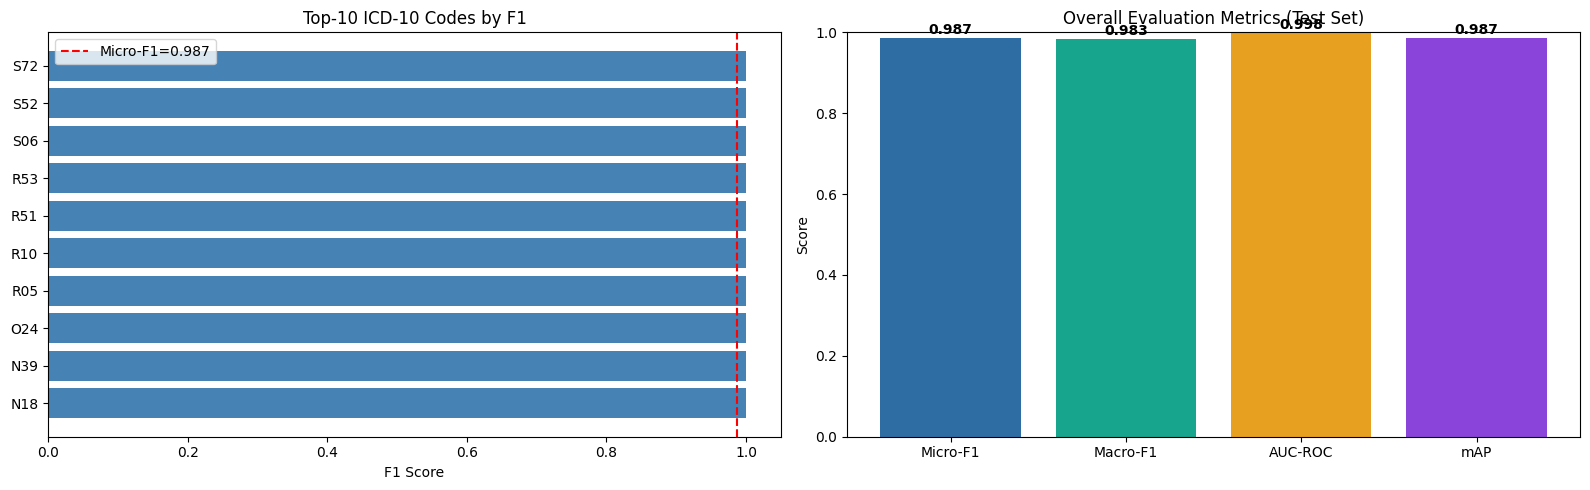

✅ Plot saved


In [11]:
import matplotlib.pyplot as plt

per_code_f1 = f1_score(labels, preds, average=None, zero_division=0)
code_names   = MLB.classes_

top10_idx   = np.argsort(per_code_f1)[::-1][:10]
top10_codes = [code_names[i] for i in top10_idx]
top10_f1    = [per_code_f1[i] for i in top10_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top10_codes[::-1], top10_f1[::-1], color="steelblue")
axes[0].set_xlabel("F1 Score")
axes[0].set_title("Top-10 ICD-10 Codes by F1")
axes[0].axvline(micro_f1, color="red", linestyle="--", label=f"Micro-F1={micro_f1:.3f}")
axes[0].legend()

metric_names = ["Micro-F1", "Macro-F1", "AUC-ROC", "mAP"]
metric_vals  = [micro_f1, macro_f1, auc if not np.isnan(auc) else 0, map_score]
axes[1].bar(metric_names, metric_vals, color=["#2E6DA4", "#17A58D", "#E8A020", "#8B44D9"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Score")
axes[1].set_title("Overall Evaluation Metrics (Test Set)")
for i, v in enumerate(metric_vals):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{LOCAL_CKPT_DIR}/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved")

## A.9 — Save Artifacts

Saves the LoRA adapter weights (~20–50 MB) and all metadata needed for inference.

In [12]:
import shutil, json, pickle
from pathlib import Path

ADAPTER_SAVE_DIR = "/content/icd_insight_adapters"
os.makedirs(ADAPTER_SAVE_DIR, exist_ok=True)

model.save_pretrained(ADAPTER_SAVE_DIR)
print(f"✅ LoRA adapter saved to {ADAPTER_SAVE_DIR}")

tokenizer.save_pretrained(ADAPTER_SAVE_DIR)
shutil.copy(MLB_PATH, f"{ADAPTER_SAVE_DIR}/label_binarizer.pkl")

with open(f"{ADAPTER_SAVE_DIR}/training_results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

shutil.copy(f"{LOCAL_CKPT_DIR}/evaluation_results.png", f"{ADAPTER_SAVE_DIR}/evaluation_results.png")

print("\nSaved files:")
for p in sorted(Path(ADAPTER_SAVE_DIR).rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.name:<40} {size_mb:>8.2f} MB")

shutil.copytree(ADAPTER_SAVE_DIR, DRIVE_CHECKPOINT_DIR, dirs_exist_ok=True)
print(f"\n✅ All artifacts backed up to Drive: {DRIVE_CHECKPOINT_DIR}")

✅ LoRA adapter saved to /content/icd_insight_adapters

Saved files:
  README.md                                    0.01 MB
  adapter_config.json                          0.00 MB
  adapter_model.safetensors                    9.36 MB
  evaluation_results.png                       0.06 MB
  label_binarizer.pkl                          0.00 MB
  special_tokens_map.json                      0.00 MB
  tokenizer.json                               3.58 MB
  tokenizer_config.json                        0.02 MB
  training_results.json                        0.00 MB

✅ All artifacts backed up to Drive: /content/checkpoints_backup


## A.10 — Download Adapters for GitHub

Run this cell to download a zip archive containing all adapter files.  
Then commit them to your GitHub repo under `checkpoints/`.

In [14]:
import shutil
from google.colab import files

zip_path = "/content/icd_insight_adapters.zip"
shutil.make_archive("/content/icd_insight_adapters", "zip", ADAPTER_SAVE_DIR)

import os
size_mb = os.path.getsize(zip_path) / 1e6
print(f"📦 Archive size: {size_mb:.1f} MB")

if size_mb > 100:
    print("⚠ File > 100 MB — you will need Git LFS for GitHub upload")
    print("  Run: git lfs install && git lfs track 'checkpoints/*.safetensors'")
else:
    print("✅ File < 100 MB — can be committed directly to GitHub")

files.download(zip_path)

print("\n" + "=" * 60)
print("NEXT STEPS → Push adapters to GitHub")
print("=" * 60)
print("""
  1. Unzip the downloaded archive
  2. Copy files to your local icd-insight/checkpoints/ folder
  3. git add checkpoints/ results/
  4. git commit -m 'Add QLoRA adapter weights after training'
  5. git push origin main

  Then open Notebook B (02_Inference_New_Summary.ipynb) to run inference!
""")

📦 Archive size: 9.4 MB
✅ File < 100 MB — can be committed directly to GitHub


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


NEXT STEPS → Push adapters to GitHub

  1. Unzip the downloaded archive
  2. Copy files to your local icd-insight/checkpoints/ folder
  3. git add checkpoints/ results/
  4. git commit -m 'Add QLoRA adapter weights after training'
  5. git push origin main

  Then open Notebook B (02_Inference_New_Summary.ipynb) to run inference!



---
## 📊 Training Summary

| Item | Value |
|------|-------|
| Base model | BioClinical ModernBERT-base |
| Strategy | QLoRA (4-bit NF4 + LoRA adapters) |
| LoRA rank | r=16, alpha=32 |
| Token length | 2048 |
| Training set | birgermoell/icd10-clinical-notes (Public HF) |
| Target codes | Top-50 ICD-10-CM |
| Loss | Focal Loss (γ=2) |
| Adapter size | ~20–50 MB |

*ICD-Insight — M.Tech Final Year Project*